In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2- Charge les fichiers CSV du dataset: 

In [4]:
#chemin vers le dossier datasets
data_path = "../datasets/ml-latest-small/"
#charger les fichiers 
movies = pd.read_csv(data_path + "movies.csv")
ratings = pd.read_csv(data_path + "ratings.csv")
tags = pd.read_csv(data_path + "tags.csv")
links = pd.read_csv(data_path + "links.csv")
#afficher premières lignes
print(movies.head())
print(ratings.head())
print(tags.head())
print(links.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   userId  movieId              tag   timestamp
0       2    60756            funny  1445714994
1       2    60756  Highly quotable  1445714996
2       2    60756     will ferre

3- EDA:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userId     3683 non-null   int64 
 1   movieId    3683 non-nul

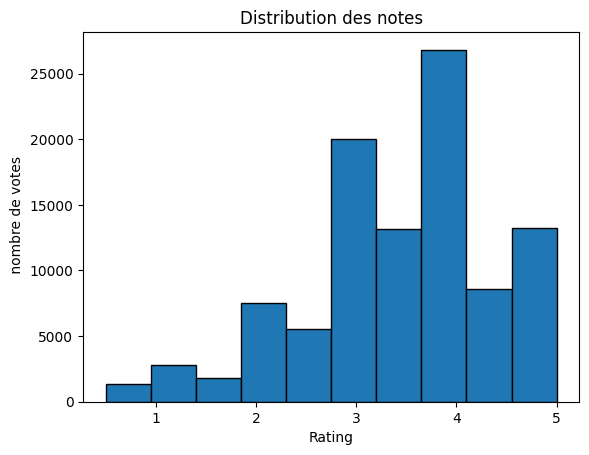

movieId
356     329
318     317
296     307
593     279
2571    278
260     251
480     238
110     237
589     224
527     220
Name: rating, dtype: int64
movieId
88448     5.0
100556    5.0
143031    5.0
143511    5.0
143559    5.0
6201      5.0
102217    5.0
102084    5.0
6192      5.0
145994    5.0
Name: rating, dtype: float64


In [5]:
#general info
movies.info()
ratings.info()
tags.info()
links.info()
#stats de base
movies.describe()
ratings.describe()
tags.describe()
links.describe()
#repartition des notes
plt.hist(ratings['rating'], bins=10, edgecolor='black')
plt.xlabel('Rating')
plt.ylabel(' nombre de votes')
plt.title('Distribution des notes')
plt.show()
#top 10 films les plus notés
top_10_movies = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False).head(10)
print(top_10_movies)
#top 10 films mieux notés
top_10_rated_movies = ratings.groupby('movieId')['rating'].mean().sort_values(ascending=False).head(10)
print(top_10_rated_movies)

4- préparer les données des films: 

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
#remplacer les genres manquants par ""
movies['genres'] = movies['genres'].fillna('')
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


5-transformer les genres en vecteurs TF-IDF: (converts text into numerical vectors by weighting words based on their importance)

In [7]:
tfidf= TfidfVectorizer(stop_words='english') #ignorer mots commmuns 'the', 'and', etc.'
tfidf_matrix = tfidf.fit_transform(movies['genres']) #chaque film representé par un vecteur, chaque dimension correspond à un genre / terme unique
print(tfidf_matrix.shape)  # (nombre de films, nombre de termes uniques)

(9742, 23)


6- Calculer Cosine Similarity: (a measure of similarity between two non-zero vectors that calculates the cosine of the angle between them)

In [8]:
cosine_sim= cosine_similarity(tfidf_matrix, tfidf_matrix) #cosine similarity entre tous les films
print(cosine_sim.shape)  # cosine_sim[i][j] = similarité entre film i et film j

(9742, 9742)


7- Créer une fonction de recommendation simple: (pour le moment content-based, on se base que sur le genre)

In [9]:
#on crée un dictionnaire pour retrouver l'index des films par leur titre
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()
def recommend(title, cosine_sim=cosine_sim):
    idx = indices[title] # obtenir l'index du film donné
    sim_scores = list(enumerate(cosine_sim[idx])) # similarité entre ce film et tous les autres en creant une liste de tuples (index du film, score de similarité)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True) # trier par similarité
    sim_scores = sim_scores[1:11]  # top 10 films similaires
    movie_indices = [i[0] for i in sim_scores] # obtenir les indices des films en liste
    return movies['title'].iloc[movie_indices] # retourner les titres des films recommandés

8- tester la recommendation: 

In [10]:
recommended_movies = recommend('Toy Story (1995)')
print(recommended_movies)
recommended_movies = recommend('Jumanji (1995)')
print(recommended_movies)
recommended_movies = recommend('Heat (1995)')
print(recommended_movies)
recommended_movies = recommend('Avatar (2009)')
print(recommended_movies)

1706                                          Antz (1998)
2355                                   Toy Story 2 (1999)
2809       Adventures of Rocky and Bullwinkle, The (2000)
3000                     Emperor's New Groove, The (2000)
3568                                Monsters, Inc. (2001)
6194                                     Wild, The (2006)
6486                               Shrek the Third (2007)
6948                       Tale of Despereaux, The (2008)
7760    Asterix and the Vikings (Astérix et les Viking...
8219                                         Turbo (2013)
Name: title, dtype: object
53                     Indian in the Cupboard, The (1995)
109                     NeverEnding Story III, The (1994)
767                       Escape to Witch Mountain (1975)
1514            Darby O'Gill and the Little People (1959)
1556                                  Return to Oz (1985)
1617                        NeverEnding Story, The (1984)
1618    NeverEnding Story II: The Next Chapte

9- Add collaborative filtering (SVD) - data preparation

In [11]:
import pandas as pd
data_path = "../datasets/ml-latest-small/"
ratings = pd.read_csv(data_path + "ratings.csv")
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [12]:
from surprise import SVD, Dataset, Reader
reader = Reader(rating_scale=(0.5, 5.0)) # définir l'échelle des notes
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader) #charger les données dans le format surprise (userId, itemId, rating)